# Stack Overflow Developer Survey Analysis  
## Automation Readiness among QA/Test Respondents

This notebook follows the approved methodology: **secondary quantitative-descriptive analysis** using the public Stack Overflow Developer Survey dataset.

It does **not** use hypothetical questionnaire data. It filters QA/test respondents and analyses automation-readiness proxy indicators such as role, coding experience, programming-language exposure, platform exposure, development environment exposure, and AI/developer-tool exposure.

Run this notebook in Google Colab or Jupyter. Upload or place the Stack Overflow survey ZIP/CSV in the same folder.


In [1]:
# 1. Import libraries and load/extract dataset

import os
import re
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import files
    IN_COLAB = True
except Exception:
    IN_COLAB = False

workdir = Path.cwd()
csv_file = workdir / "survey_results_public.csv"

if not csv_file.exists():
    zip_files = list(workdir.glob("*.zip"))
    if IN_COLAB and not zip_files:
        print("/content/stack-overflow-developer-survey-2025 (2).zip.")
        uploaded = files.upload()
        zip_files = [Path(name) for name in uploaded.keys() if name.lower().endswith(".zip")]

    if zip_files:
        print("Extracting:", zip_files[0])
        with zipfile.ZipFile(zip_files[0], "r") as z:
            z.extractall(workdir)
    else:
        raise FileNotFoundError("No ZIP or survey_results_public.csv found.")

if not csv_file.exists():
    raise FileNotFoundError("survey_results_public.csv not found after extraction.")

df = pd.read_csv(csv_file, low_memory=False)
print("Dataset loaded:", df.shape)
print("Columns:", len(df.columns))


Extracting: /content/stack-overflow-developer-survey-2025 (2).zip
Dataset loaded: (49191, 172)
Columns: 172


In [2]:
# 2. Select variables linked to automation-readiness proxy indicators

possible_cols = [
    "ResponseId", "DevType", "YearsCode", "YearsCodePro", "WorkExp", "EdLevel",
    "LearnCode", "LearnCodeChoose", "LearnCodeAI",
    "LanguageHaveWorkedWith", "LanguageWantToWorkWith",
    "DatabaseHaveWorkedWith", "DatabaseWantToWorkWith",
    "PlatformHaveWorkedWith", "PlatformWantToWorkWith",
    "WebframeHaveWorkedWith", "WebframeWantToWorkWith",
    "DevEnvsHaveWorkedWith", "DevEnvsWantToWorkWith",
    "ToolsTechHaveWorkedWith", "ToolsTechWantToWorkWith",
    "NEWCollabToolsHaveWorkedWith", "NEWCollabToolsWantToWorkWith",
    "OfficeStackAsyncHaveWorkedWith", "OfficeStackSyncHaveWorkedWith",
    "CommPlatformHaveWorkedWith",
    "AISelect", "AISent", "AIAcc", "AIComplex",
    "AISearchHaveWorkedWith", "AISearchWantToWorkWith",
    "AIDevHaveWorkedWith", "AIDevWantToWorkWith",
    "AIModelsHaveWorkedWith", "AIModelsWantToWorkWith",
    "AIAgents", "AIAgent_Uses", "AIHuman", "AIOpen"
]

selected_cols = [c for c in possible_cols if c in df.columns]
missing_cols = [c for c in possible_cols if c not in df.columns]

working_df = df[selected_cols].copy()

print("Selected columns:", len(selected_cols))
print(selected_cols)
print("\nMissing requested columns:", missing_cols)


Selected columns: 30
['ResponseId', 'DevType', 'YearsCode', 'WorkExp', 'EdLevel', 'LearnCode', 'LearnCodeChoose', 'LearnCodeAI', 'LanguageHaveWorkedWith', 'LanguageWantToWorkWith', 'DatabaseHaveWorkedWith', 'DatabaseWantToWorkWith', 'PlatformHaveWorkedWith', 'PlatformWantToWorkWith', 'WebframeHaveWorkedWith', 'WebframeWantToWorkWith', 'DevEnvsHaveWorkedWith', 'DevEnvsWantToWorkWith', 'OfficeStackAsyncHaveWorkedWith', 'CommPlatformHaveWorkedWith', 'AISelect', 'AISent', 'AIAcc', 'AIComplex', 'AIModelsHaveWorkedWith', 'AIModelsWantToWorkWith', 'AIAgents', 'AIAgent_Uses', 'AIHuman', 'AIOpen']

Missing requested columns: ['YearsCodePro', 'ToolsTechHaveWorkedWith', 'ToolsTechWantToWorkWith', 'NEWCollabToolsHaveWorkedWith', 'NEWCollabToolsWantToWorkWith', 'OfficeStackSyncHaveWorkedWith', 'AISearchHaveWorkedWith', 'AISearchWantToWorkWith', 'AIDevHaveWorkedWith', 'AIDevWantToWorkWith']


In [3]:
# 3. Filter QA/test respondents

if "DevType" not in working_df.columns:
    raise KeyError("DevType column not available, so QA/test filtering cannot be performed.")

qa_test_df = working_df[
    working_df["DevType"].astype(str).str.contains("Developer, QA or test", na=False, regex=False)
].copy()

readiness_cols = [c for c in selected_cols if c not in ["ResponseId", "DevType"]]

usable_qa_test_df = qa_test_df[
    qa_test_df[readiness_cols].notna().any(axis=1)
].copy()

usable_qa_test_df.to_csv("filtered_qa_test_respondents.csv", index=False)

counts_df = pd.DataFrame([
    ["Total survey responses", "len(df)", len(df)],
    ["Responses with valid DevType", 'df["DevType"].notna().sum()', int(df["DevType"].notna().sum())],
    ["QA/test respondents", 'DevType contains "Developer, QA or test"', len(qa_test_df)],
    ["Final usable QA/test sample", "QA/test respondents with at least one readiness-related variable", len(usable_qa_test_df)]
], columns=["Item", "Query / Condition", "Count"])

counts_df.to_csv("filtered_database_counts.csv", index=False)
display(counts_df)
print("Filtered database saved as: filtered_qa_test_respondents.csv")


,Item,Query / Condition,Count
0,Total survey responses,len(df),49191
1,Responses with valid DevType,"df[""DevType""].notna().sum()",43680
2,QA/test respondents,"DevType contains ""Developer, QA or test""",343
3,Final usable QA/test sample,QA/test respondents with at least one readines...,343


Filtered database saved as: filtered_qa_test_respondents.csv


In [4]:
# 4. Selected variables table for methodology and Chapter 4

proxy_map = {
    "ResponseId": ("Anonymous response identifier", "Case identifier"),
    "DevType": ("Filters QA/test respondents", "Testing-oriented role"),
    "YearsCode": ("Shows total coding experience", "Technical maturity"),
    "YearsCodePro": ("Shows professional coding experience", "Professional technical maturity"),
    "WorkExp": ("Shows work experience", "Professional/work maturity"),
    "EdLevel": ("Shows education level", "Educational background"),
    "LearnCode": ("Shows learning background", "Learning pathway"),
    "LanguageHaveWorkedWith": ("Shows programming-language exposure", "Automation scripting readiness"),
    "DatabaseHaveWorkedWith": ("Shows database exposure", "Software environment familiarity"),
    "PlatformHaveWorkedWith": ("Shows platform/cloud exposure", "Modern software environment familiarity"),
    "WebframeHaveWorkedWith": ("Shows web framework exposure", "Web automation context"),
    "DevEnvsHaveWorkedWith": ("Shows development environment exposure", "Practical tool ecosystem familiarity"),
    "ToolsTechHaveWorkedWith": ("Shows tool/technology exposure", "Automation-related tool familiarity"),
    "NEWCollabToolsHaveWorkedWith": ("Shows collaboration/developer tool exposure", "Practical tool ecosystem familiarity"),
    "AISelect": ("Shows whether AI tools are used", "Modern development practice"),
    "AISent": ("Shows attitude toward AI tools", "AI adoption attitude"),
    "AIAcc": ("Shows trust in AI output accuracy", "AI evaluation awareness"),
    "AIComplex": ("Shows perceived complexity handling by AI", "AI capability perception"),
    "AISearchHaveWorkedWith": ("Shows AI search-tool exposure", "Emerging AI tool exposure"),
    "AIDevHaveWorkedWith": ("Shows AI developer-tool exposure", "AI-supported development exposure"),
    "AIModelsHaveWorkedWith": ("Shows AI model exposure", "AI ecosystem exposure"),
    "AIAgents": ("Shows AI-agent use", "Emerging AI-agent exposure"),
    "AIAgent_Uses": ("Shows AI-agent use cases", "AI workflow exposure"),
    "AIHuman": ("Shows when human support remains preferred", "Human judgement relevance"),
    "AIOpen": ("Shows views on future skills with AI", "Future skill relevance")
}

rows = []
for c in selected_cols:
    purpose, proxy = proxy_map.get(c, ("Relevant survey variable used in analysis", "Contextual variable"))
    rows.append([c, purpose, proxy])

variables_df = pd.DataFrame(rows, columns=["Variable", "Purpose in the Study", "Proxy Meaning"])
variables_df.to_csv("selected_variables_table.csv", index=False)
display(variables_df)


,Variable,Purpose in the Study,Proxy Meaning
0,ResponseId,Anonymous response identifier,Case identifier
1,DevType,Filters QA/test respondents,Testing-oriented role
2,YearsCode,Shows total coding experience,Technical maturity
3,WorkExp,Shows work experience,Professional/work maturity
4,EdLevel,Shows education level,Educational background
5,LearnCode,Shows learning background,Learning pathway
6,LearnCodeChoose,Relevant survey variable used in analysis,Contextual variable
7,LearnCodeAI,Relevant survey variable used in analysis,Contextual variable
8,LanguageHaveWorkedWith,Shows programming-language exposure,Automation scripting readiness
9,LanguageWantToWorkWith,Relevant survey variable used in analysis,Contextual variable


In [5]:
# 5. Experience cleaning and summary

def clean_years(x):
    if pd.isna(x):
        return np.nan
    text = str(x).strip().lower()
    if "less than" in text:
        return 0.5
    if "more than 50" in text or "50 or more" in text:
        return 51
    m = re.search(r"\d+", text)
    return float(m.group()) if m else np.nan

experience_rows = []

for col in ["YearsCode", "YearsCodePro", "WorkExp"]:
    if col in usable_qa_test_df.columns:
        clean_col = col + "_Clean"
        if col == "WorkExp":
            usable_qa_test_df[clean_col] = pd.to_numeric(usable_qa_test_df[col], errors="coerce")
        else:
            usable_qa_test_df[clean_col] = usable_qa_test_df[col].apply(clean_years)

        s = usable_qa_test_df[clean_col].dropna()
        if len(s) > 0:
            experience_rows.append([col, len(s), round(s.mean(), 2), round(s.median(), 2), round(s.min(), 2), round(s.max(), 2)])

experience_summary_df = pd.DataFrame(experience_rows, columns=["Variable", "N", "Mean", "Median", "Minimum", "Maximum"])
experience_summary_df.to_csv("experience_summary.csv", index=False)
display(experience_summary_df)


,Variable,N,Mean,Median,Minimum,Maximum
0,YearsCode,336,12.47,10.0,1.0,48.0
1,WorkExp,330,11.09,8.0,1.0,47.0


In [6]:
# 6. Multi-response frequency tables

def top_multi_response(data, column, top_n=15):
    if column not in data.columns:
        return pd.DataFrame()
    values = data[column].dropna().astype(str).str.split(";").explode().str.strip()
    values = values[values != ""]
    out = values.value_counts().head(top_n).reset_index()
    out.columns = [column, "Count"]
    out["Percentage_of_QA_Test_Sample"] = round(out["Count"] / len(data) * 100, 2)
    return out

multi_cols = [
    "LanguageHaveWorkedWith", "DatabaseHaveWorkedWith", "PlatformHaveWorkedWith",
    "WebframeHaveWorkedWith", "DevEnvsHaveWorkedWith", "ToolsTechHaveWorkedWith",
    "NEWCollabToolsHaveWorkedWith", "AISearchHaveWorkedWith",
    "AIDevHaveWorkedWith", "AIModelsHaveWorkedWith"
]

top_tables = {}
for col in multi_cols:
    if col in usable_qa_test_df.columns:
        table = top_multi_response(usable_qa_test_df, col)
        top_tables[col] = table
        table.to_csv(f"top_{col}.csv", index=False)
        print("\nTop values for", col)
        display(table)



Top values for LanguageHaveWorkedWith


,LanguageHaveWorkedWith,Count,Percentage_of_QA_Test_Sample
0,Python,162,47.23
1,JavaScript,157,45.77
2,Bash/Shell (all shells),130,37.90
3,SQL,122,35.57
4,HTML/CSS,120,34.99
5,TypeScript,93,27.11
6,Java,88,25.66
7,PowerShell,69,20.12
8,C#,58,16.91
9,C++,48,13.99



Top values for DatabaseHaveWorkedWith


,DatabaseHaveWorkedWith,Count,Percentage_of_QA_Test_Sample
0,PostgreSQL,86,25.07
1,Microsoft SQL Server,73,21.28
2,MySQL,72,20.99
3,SQLite,49,14.29
4,MongoDB,42,12.24
5,Elasticsearch,35,10.20
6,Redis,33,9.62
7,Oracle,30,8.75
8,MariaDB,28,8.16
9,Dynamodb,13,3.79



Top values for PlatformHaveWorkedWith


...

,WebframeHaveWorkedWith,Count,Percentage_of_QA_Test_Sample
0,Node.js,76,22.16
1,React,64,18.66
2,Angular,30,8.75
3,jQuery,27,7.87
4,Spring Boot,27,7.87
5,ASP.NET,25,7.29
6,WordPress,24,7.00
7,ASP.NET Core,24,7.00
8,Express,24,7.00
9,Flask,21,6.12



Top values for DevEnvsHaveWorkedWith


,DevEnvsHaveWorkedWith,Count,Percentage_of_QA_Test_Sample
0,Visual Studio Code,155,45.19
1,IntelliJ IDEA,74,21.57
2,Notepad++,72,20.99
3,Vim,54,15.74
4,PyCharm,54,15.74
5,Visual Studio,47,13.70
6,Android Studio,32,9.33
7,Nano,27,7.87
8,Cursor,26,7.58
9,Claude Code,21,6.12



Top values for AIModelsHaveWorkedWith


,AIModelsHaveWorkedWith,Count,Percentage_of_QA_Test_Sample
0,openAI GPT (chatbot models),106,30.90
1,Anthropic: Claude Sonnet,54,15.74
2,Gemini (Flash general purpose models),52,15.16
3,openAI Reasoning models,39,11.37
4,Gemini (Pro Reasoning models),33,9.62
5,DeepSeek (R- Reasoning models),29,8.45
6,openAI Image generating models,28,8.16
7,Meta Llama (all models),24,7.00
8,DeepSeek (V- General purpose models),19,5.54
9,X Grok models,18,5.25


In [7]:
# 7. Exploratory proxy automation-readiness profile

profile_df = usable_qa_test_df.copy()

profile_df["Has_Coding_Experience"] = False
if "YearsCode_Clean" in profile_df.columns:
    profile_df["Has_Coding_Experience"] = profile_df["YearsCode_Clean"].fillna(0) > 0

profile_df["Has_Professional_Experience"] = False
if "YearsCodePro_Clean" in profile_df.columns:
    profile_df["Has_Professional_Experience"] = profile_df["YearsCodePro_Clean"].fillna(0) > 0
elif "WorkExp_Clean" in profile_df.columns:
    profile_df["Has_Professional_Experience"] = profile_df["WorkExp_Clean"].fillna(0) > 0

profile_df["Has_Language_Exposure"] = profile_df["LanguageHaveWorkedWith"].notna() if "LanguageHaveWorkedWith" in profile_df.columns else False
profile_df["Has_Platform_Exposure"] = profile_df["PlatformHaveWorkedWith"].notna() if "PlatformHaveWorkedWith" in profile_df.columns else False
profile_df["Has_Webframe_Exposure"] = profile_df["WebframeHaveWorkedWith"].notna() if "WebframeHaveWorkedWith" in profile_df.columns else False
profile_df["Has_DevEnv_Exposure"] = profile_df["DevEnvsHaveWorkedWith"].notna() if "DevEnvsHaveWorkedWith" in profile_df.columns else False

ai_cols = [c for c in ["AISelect", "AISearchHaveWorkedWith", "AIDevHaveWorkedWith", "AIModelsHaveWorkedWith", "AIAgents"] if c in profile_df.columns]
profile_df["Has_AI_Exposure"] = profile_df[ai_cols].notna().any(axis=1) if ai_cols else False

flags = [
    "Has_Coding_Experience", "Has_Professional_Experience", "Has_Language_Exposure",
    "Has_Platform_Exposure", "Has_Webframe_Exposure", "Has_DevEnv_Exposure", "Has_AI_Exposure"
]

profile_df["Proxy_Readiness_Score"] = profile_df[flags].sum(axis=1)
profile_df["Proxy_Readiness_Level"] = pd.cut(
    profile_df["Proxy_Readiness_Score"],
    bins=[-1, 2, 4, 7],
    labels=["Lower proxy readiness", "Moderate proxy readiness", "Higher proxy readiness"]
)

readiness_summary = profile_df["Proxy_Readiness_Level"].value_counts(dropna=False).reset_index()
readiness_summary.columns = ["Proxy_Readiness_Level", "Count"]
readiness_summary["Percentage"] = round(readiness_summary["Count"] / len(profile_df) * 100, 2)

readiness_summary.to_csv("proxy_readiness_profile_summary.csv", index=False)
profile_df.to_csv("filtered_qa_test_respondents_with_proxy_scores.csv", index=False)

display(readiness_summary)


,Proxy_Readiness_Level,Count,Percentage
0,Higher proxy readiness,227,66.18
1,Lower proxy readiness,71,20.70
2,Moderate proxy readiness,45,13.12


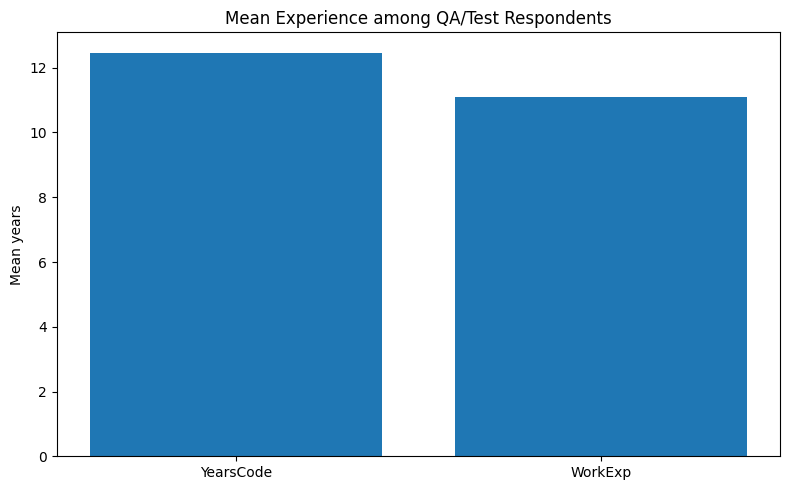

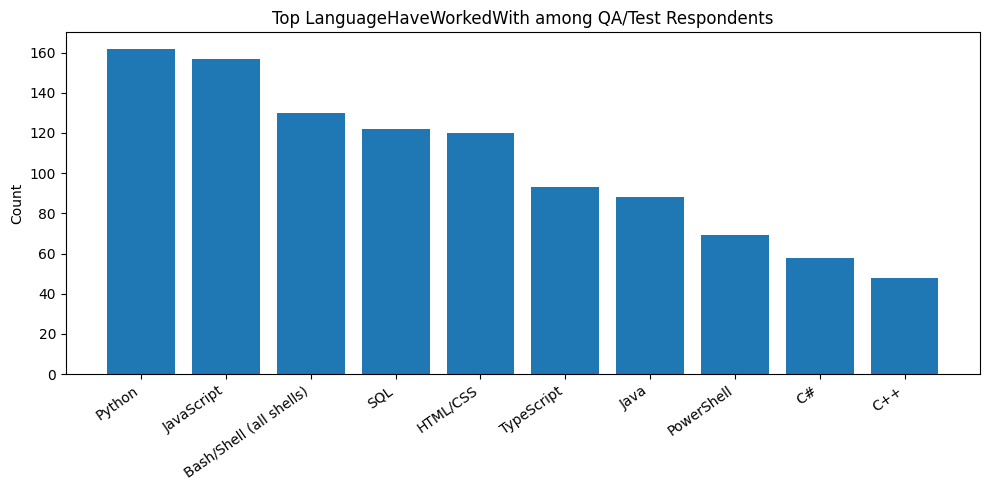

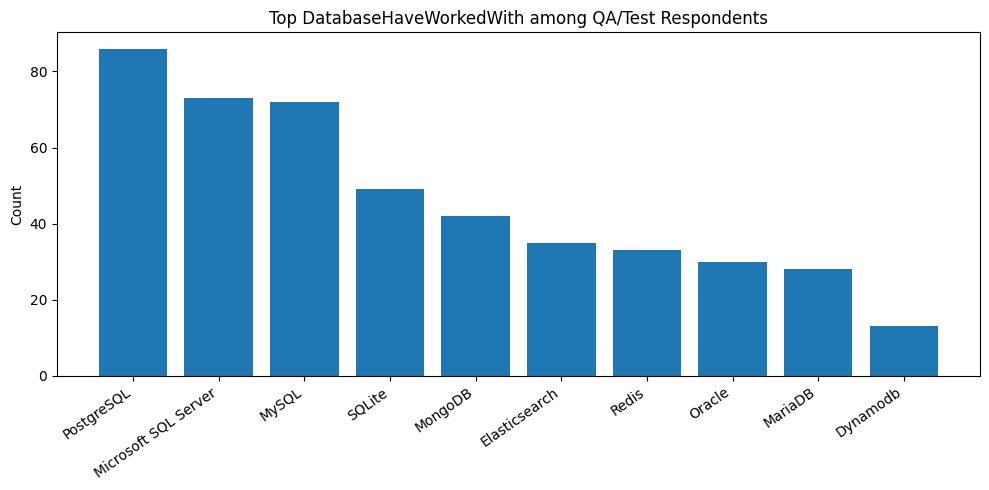

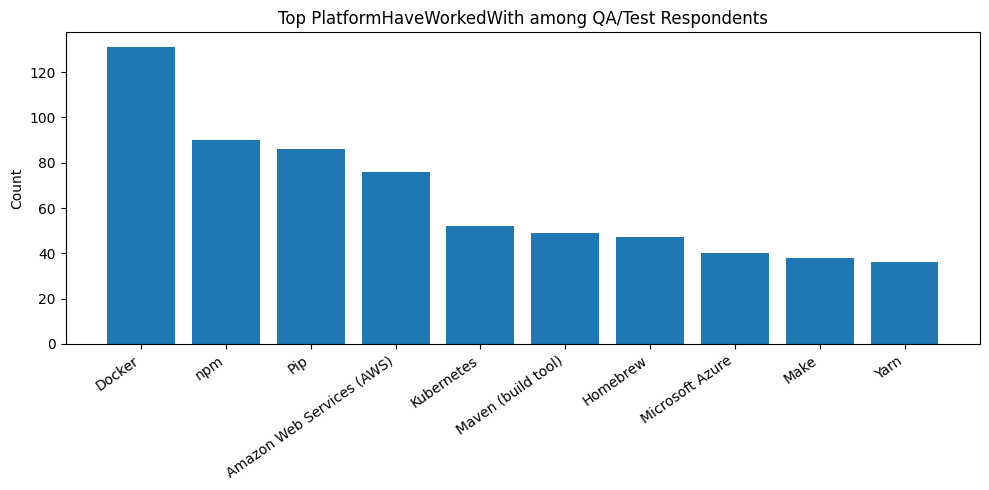

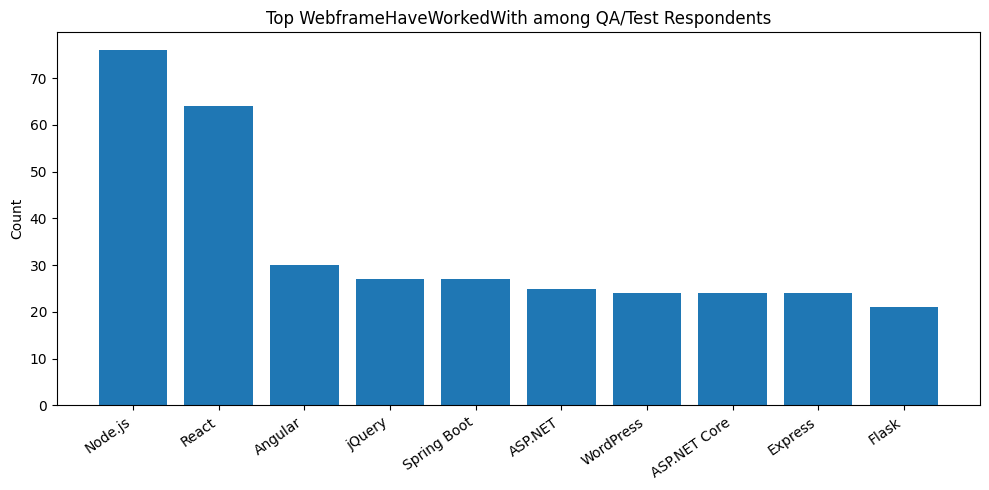

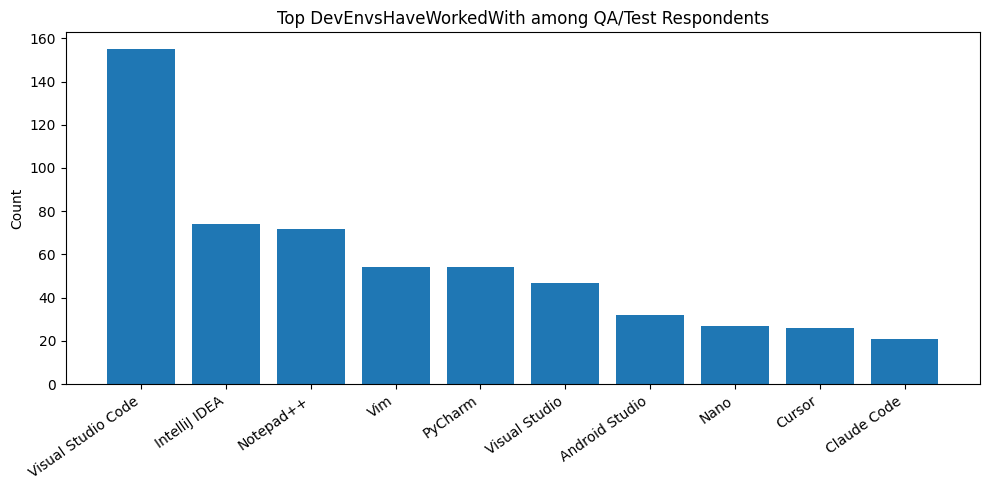

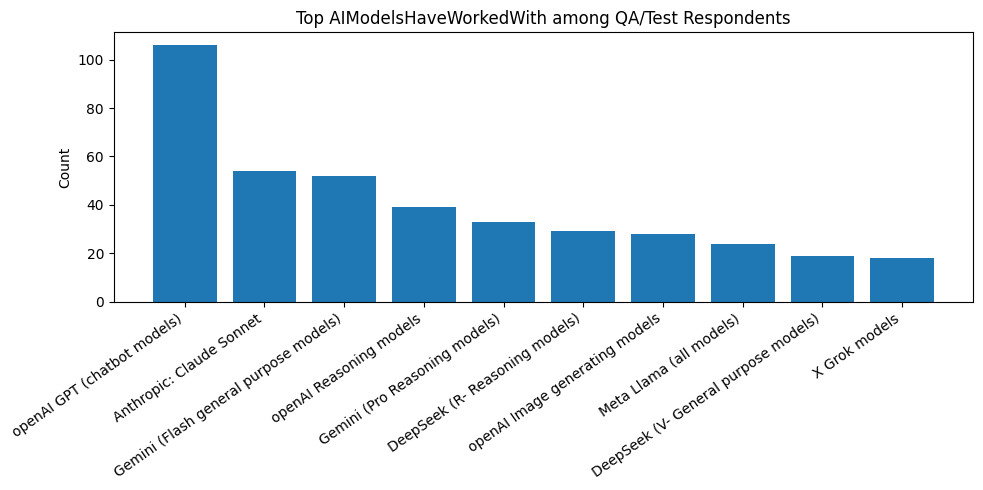

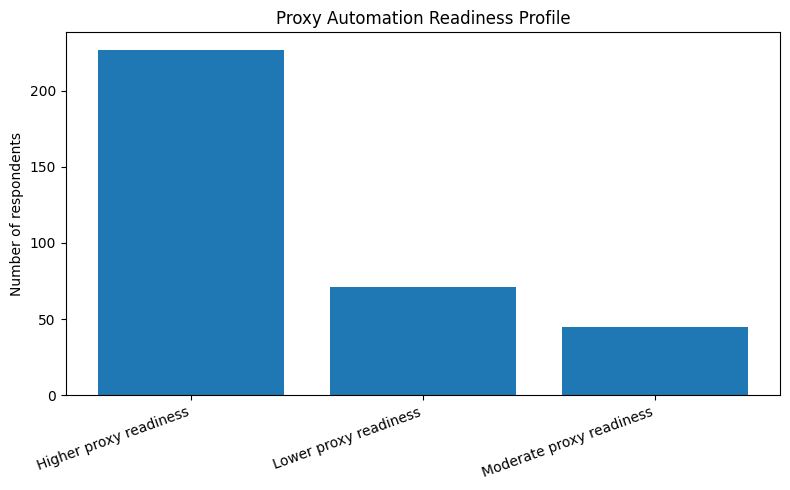

Charts created: ['chart_experience_summary.png', 'chart_top_LanguageHaveWorkedWith.png', 'chart_top_DatabaseHaveWorkedWith.png', 'chart_top_PlatformHaveWorkedWith.png', 'chart_top_WebframeHaveWorkedWith.png', 'chart_top_DevEnvsHaveWorkedWith.png', 'chart_top_AIModelsHaveWorkedWith.png', 'chart_proxy_readiness_profile.png']


In [8]:
# 8. Create charts for Chapter 4

chart_files = []

if not experience_summary_df.empty:
    plt.figure(figsize=(8, 5))
    plt.bar(experience_summary_df["Variable"], experience_summary_df["Mean"])
    plt.ylabel("Mean years")
    plt.title("Mean Experience among QA/Test Respondents")
    plt.tight_layout()
    plt.savefig("chart_experience_summary.png", dpi=200)
    plt.show()
    chart_files.append("chart_experience_summary.png")

for col, table in top_tables.items():
    if not table.empty:
        plt.figure(figsize=(10, 5))
        plot_table = table.head(10)
        plt.bar(plot_table[col].astype(str), plot_table["Count"])
        plt.xticks(rotation=35, ha="right")
        plt.ylabel("Count")
        plt.title(f"Top {col} among QA/Test Respondents")
        plt.tight_layout()
        fname = f"chart_top_{col}.png"
        plt.savefig(fname, dpi=200)
        plt.show()
        chart_files.append(fname)

plt.figure(figsize=(8, 5))
plt.bar(readiness_summary["Proxy_Readiness_Level"].astype(str), readiness_summary["Count"])
plt.ylabel("Number of respondents")
plt.title("Proxy Automation Readiness Profile")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("chart_proxy_readiness_profile.png", dpi=200)
plt.show()
chart_files.append("chart_proxy_readiness_profile.png")

print("Charts created:", chart_files)


In [9]:
# 9. Generate Chapter 4 ready text

total = int(counts_df.loc[counts_df["Item"] == "Total survey responses", "Count"].iloc[0])
valid = int(counts_df.loc[counts_df["Item"] == "Responses with valid DevType", "Count"].iloc[0])
qa = int(counts_df.loc[counts_df["Item"] == "QA/test respondents", "Count"].iloc[0])
usable = int(counts_df.loc[counts_df["Item"] == "Final usable QA/test sample", "Count"].iloc[0])

def top_text(col, label_col=None, n=5):
    if col not in top_tables or top_tables[col].empty:
        return "not available"
    label_col = label_col or col
    return ", ".join([f'{r[label_col]} ({r["Count"]})' for _, r in top_tables[col].head(n).iterrows()])

exp_text = ""
if not experience_summary_df.empty:
    exp_text = "; ".join([f'{r["Variable"]}: mean {r["Mean"]}, median {r["Median"]}, N={r["N"]}' for _, r in experience_summary_df.iterrows()])

readiness_text = "; ".join([f'{r["Proxy_Readiness_Level"]}: {r["Count"]} ({r["Percentage"]}%)' for _, r in readiness_summary.iterrows()])

chapter4_text = f'''Chapter 4 Results Text

The Stack Overflow Developer Survey dataset contained {total:,} responses. Of these, {valid:,} responses had valid DevType role information. The filtering query selected respondents whose DevType value contained "Developer, QA or test", producing {qa:,} QA/test respondents. After checking that each filtered case had at least one readiness-related variable available, the final usable QA/test sample remained {usable:,} respondents.

The filtered database was exported as filtered_qa_test_respondents.csv. This dataset should be interpreted as a QA/test professional subset rather than as a direct sample of manual testers or automation testers.

The experience summary was: {exp_text}. These indicators provide a proxy for technical maturity, but they do not directly prove automation competence.

Programming-language exposure was used as a proxy for automation scripting readiness. The most frequent programming languages among QA/test respondents were: {top_text("LanguageHaveWorkedWith")}.

Platform exposure was used as a proxy for familiarity with modern software delivery environments. The most common platforms were: {top_text("PlatformHaveWorkedWith")}.

Development environment exposure was used as a proxy for practical tool ecosystem familiarity. The most common development environments were: {top_text("DevEnvsHaveWorkedWith")}.

The exploratory proxy readiness profile was: {readiness_text}. This profile is proxy-based and should not be interpreted as a validated automation-readiness scale.
'''

with open("chapter4_stackoverflow_results_text.txt", "w", encoding="utf-8") as f:
    f.write(chapter4_text)

print(chapter4_text)


Chapter 4 Results Text

The Stack Overflow Developer Survey dataset contained 49,191 responses. Of these, 43,680 responses had valid DevType role information. The filtering query selected respondents whose DevType value contained "Developer, QA or test", producing 343 QA/test respondents. After checking that each filtered case had at least one readiness-related variable available, the final usable QA/test sample remained 343 respondents.

The filtered database was exported as filtered_qa_test_respondents.csv. This dataset should be interpreted as a QA/test professional subset rather than as a direct sample of manual testers or automation testers.

The experience summary was: YearsCode: mean 12.47, median 10.0, N=336; WorkExp: mean 11.09, median 8.0, N=330. These indicators provide a proxy for technical maturity, but they do not directly prove automation competence.

Programming-language exposure was used as a proxy for automation scripting readiness. The most frequent programming langu

In [10]:
# 10. Zip all outputs for submission / GitHub

output_files = [
    "filtered_qa_test_respondents.csv",
    "filtered_database_counts.csv",
    "selected_variables_table.csv",
    "experience_summary.csv",
    "proxy_readiness_profile_summary.csv",
    "filtered_qa_test_respondents_with_proxy_scores.csv",
    "chapter4_stackoverflow_results_text.txt"
]

output_files += [str(p.name) for p in Path.cwd().glob("top_*.csv")]
output_files += chart_files

existing_files = []
for f in output_files:
    if Path(f).exists() and f not in existing_files:
        existing_files.append(f)

zip_name = "stackoverflow_methodology_outputs.zip"
with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as z:
    for f in existing_files:
        z.write(f)

print("Created:", zip_name)
print("Files included:")
for f in existing_files:
    print("-", f)

if IN_COLAB:
    files.download(zip_name)


Created: stackoverflow_methodology_outputs.zip
Files included:
- filtered_qa_test_respondents.csv
- filtered_database_counts.csv
- selected_variables_table.csv
- experience_summary.csv
- proxy_readiness_profile_summary.csv
- filtered_qa_test_respondents_with_proxy_scores.csv
- chapter4_stackoverflow_results_text.txt
- top_AIModelsHaveWorkedWith.csv
- top_WebframeHaveWorkedWith.csv
- top_LanguageHaveWorkedWith.csv
- top_DevEnvsHaveWorkedWith.csv
- top_DatabaseHaveWorkedWith.csv
- top_PlatformHaveWorkedWith.csv
- chart_experience_summary.png
- chart_top_LanguageHaveWorkedWith.png
- chart_top_DatabaseHaveWorkedWith.png
- chart_top_PlatformHaveWorkedWith.png
- chart_top_WebframeHaveWorkedWith.png
- chart_top_DevEnvsHaveWorkedWith.png
- chart_top_AIModelsHaveWorkedWith.png
- chart_proxy_readiness_profile.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>